# Results-Only Uncertainty Plots

This notebook generates publication-style uncertainty trend plots directly from saved `results/*.pkl` files.

## What this notebook does
- Uses local result files (no MNIST image loading)
- Normalizes severity levels to: `plain`, `low_severity`, `mid_severity`, `high_severity`
- Reuses the existing visualization helper function
- Saves plots to `plots/results_only/`

## Run order
1. Run the setup cell
2. Run the helper functions cell
3. Run the load/build cell
4. Run the plotting cell
5. Run the metrics summary cell

In [1]:
from pathlib import Path
import pickle
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

import sys

# Find repository root so imports and paths work from any working directory.
_cwd = Path.cwd()
_repo_root = next((p for p in [_cwd, *_cwd.parents] if (p / 'requirements.txt').exists()), _cwd)
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from src.utils.visualization import moving_out_of_distribution_compare

RESULTS_ROOT = _repo_root / 'results'
OUTPUT_DIR = _repo_root / 'plots' / 'results_only'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

legened_map = {
    'mc_dropout': 'MC Dropout',
    'ensemble': 'Deep Ensemble',
    'swag': 'SWAG',
    'laplace_approximation': 'Laplace Approximation',
    'ddu': 'DDU',
    'TTA': 'Test-Time Augmentation',
    'het_xl': 'HET-XL',
    'entropy': 'Entropy',
}

# Methods used for these plots.
method_keys = ['mc_dropout', 'swag', 'laplace_approximation', 'ddu', 'TTA', 'het_xl', 'entropy']

colors = sns.color_palette('tab10', len(legened_map.values()))
palette_dict = dict(zip(legened_map.values(), colors))

print('Repository root:', _repo_root)
print('Results root:', RESULTS_ROOT)
print('Output dir:', OUTPUT_DIR)

Repository root: /Users/sarasterlie/uncertainty-benchmark
Results root: /Users/sarasterlie/uncertainty-benchmark/results
Output dir: /Users/sarasterlie/uncertainty-benchmark/plots/results_only


In [2]:
METHOD_DIR_MAP = {
    'mc_dropout': 'mc_dropout',
    'ensemble': 'ensemble',
    'swag': 'swag',
    'laplace_approximation': 'laplace_approximation',
    'ddu': 'ddu',
    'TTA': 'tta',
    'het_xl': 'het_xl',
    'entropy': 'entropy',
}

LEVEL_NORMALIZE = {
    'low_sever': 'low_severity',
    'med_sever': 'mid_severity',
    'high_sever': 'high_severity',
}
SEVERITY_ORDER = ['plain', 'low_severity', 'mid_severity', 'high_severity']

def _safe_numpy(x):
    if hasattr(x, 'detach'):
        x = x.detach().cpu().numpy()
    elif hasattr(x, 'cpu'):
        x = x.cpu().numpy()
    return np.asarray(x)

def _norm_level(level):
    return LEVEL_NORMALIZE.get(level, level)

def load_method_result_files(method_name):
    method_dir = RESULTS_ROOT / METHOD_DIR_MAP[method_name]
    files = sorted(method_dir.glob('validset_uncertainty_*.pkl'))
    out = {}
    for f in files:
        level = f.stem.replace('validset_uncertainty_', '')
        with open(f, 'rb') as fh:
            out[_norm_level(level)] = pickle.load(fh)
    return out

In [4]:
# Build a clean structure expected by moving_out_of_distribution_compare().
all_uncertainty_compare = {'validset': {}}
rows = []

available_methods = []
for method in method_keys:
    method_dir = RESULTS_ROOT / METHOD_DIR_MAP.get(method, method)
    if not method_dir.exists():
        continue

    method_data = load_method_result_files(method)
    by_level = OrderedDict((lvl, method_data[lvl]) for lvl in SEVERITY_ORDER if lvl in method_data)
    if not by_level:
        continue

    all_uncertainty_compare['validset'][method] = by_level
    available_methods.append(method)

    for level, data in by_level.items():
        gt = _safe_numpy(data['ground_truth'])
        pred = _safe_numpy(data['predictions'])
        pred_labels = _safe_numpy(data['predicted_labels'])
        if pred.ndim > 2:
            pred = np.mean(pred, axis=0)

        rows.append({
            'method': legened_map.get(method, method),
            'level': level,
            'classification_auroc': roc_auc_score(gt, pred, multi_class='ovr'),
            'misclassification_auroc': roc_auc_score((pred_labels != gt).astype(int), _safe_numpy(data['total_uncertainty'])),
            'mean_total_uncertainty': _safe_numpy(data['total_uncertainty']).mean(),
            'mean_aleatoric_uncertainty': _safe_numpy(data['aleatoric_uncertainty']).mean(),
            'mean_epistemic_uncertainty': _safe_numpy(data['epistemic_uncertainty']).mean(),
        })

results_df = pd.DataFrame(rows)
print('Available methods:', available_methods)
print('Rows in metrics table:', len(results_df))
display(results_df.head(10))

Available methods: ['mc_dropout', 'swag', 'laplace_approximation', 'ddu', 'TTA', 'het_xl', 'entropy']
Rows in metrics table: 28


,method,level,classification_auroc,misclassification_auroc,mean_total_uncertainty,mean_aleatoric_uncertainty,mean_epistemic_uncertainty
0,MC Dropout,plain,0.983379,0.866863,0.796064,0.695040,1.010235e-01
1,MC Dropout,low_severity,0.983215,0.858996,0.861880,0.767418,9.446272e-02
2,MC Dropout,mid_severity,0.977146,0.800688,1.140123,1.051860,8.826296e-02
3,MC Dropout,high_severity,0.963428,0.801474,1.362872,1.281589,8.128350e-02
4,SWAG,plain,0.500000,0.500000,2.302585,2.302585,-2.384186e-07
5,SWAG,low_severity,0.500000,0.500000,2.302585,2.302585,-2.384186e-07
6,SWAG,mid_severity,0.500000,0.500000,2.302585,2.302585,-2.384186e-07
7,SWAG,high_severity,0.500000,0.500000,2.302585,2.302585,-2.384186e-07
8,Laplace Approximation,plain,0.999764,0.972817,0.051797,0.051638,1.589272e-04
9,Laplace Approximation,low_severity,0.999675,0.967833,0.067290,0.067107,1.834052e-04


Saved: /Users/sarasterlie/uncertainty-benchmark/plots/results_only/total_uncertainty_moving_out_of_distribution_compare_results_only.pdf


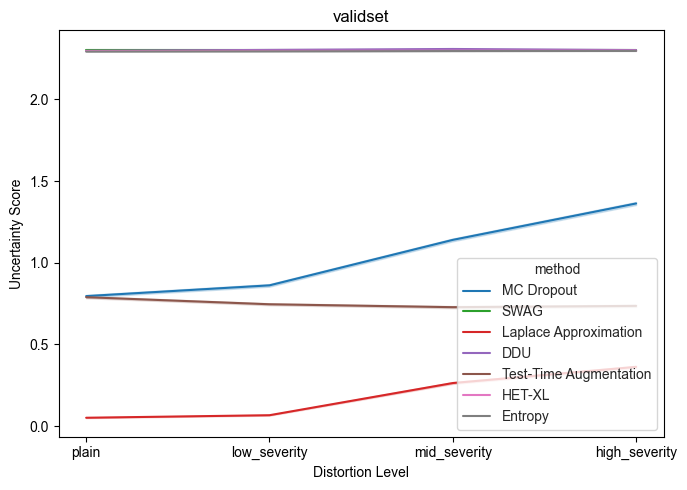

Saved: /Users/sarasterlie/uncertainty-benchmark/plots/results_only/aleatoric_uncertainty_moving_out_of_distribution_compare_results_only.pdf


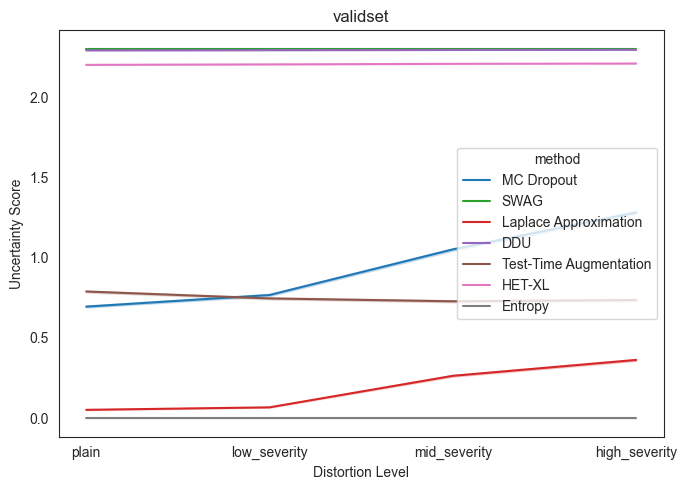

Saved: /Users/sarasterlie/uncertainty-benchmark/plots/results_only/epistemic_uncertainty_moving_out_of_distribution_compare_results_only.pdf


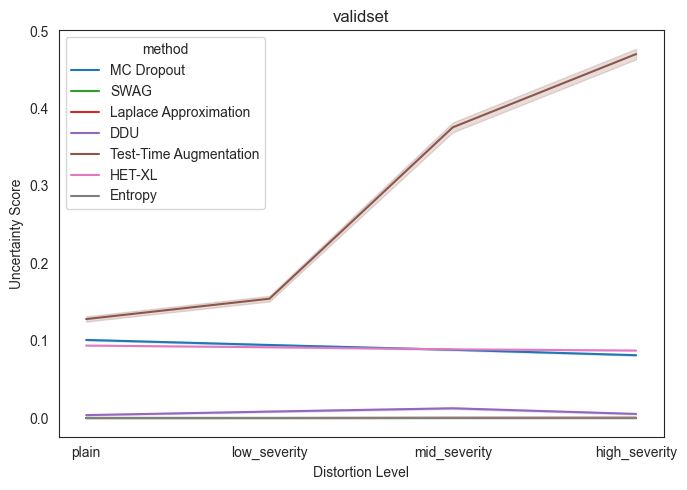

In [5]:
# Create the same style of plots as the original workflow.
plot_palette = {
    k: v for k, v in palette_dict.items()
    if k in [legened_map.get(m, m) for m in available_methods]
}

for u_type in ['total_uncertainty', 'aleatoric_uncertainty', 'epistemic_uncertainty']:
    plot = moving_out_of_distribution_compare(
        all_uncertainty_compare,
        legend_map=legened_map,
        palette=plot_palette,
        uncertainty_type=u_type
    )
    out_file = OUTPUT_DIR / f'{u_type}_moving_out_of_distribution_compare_results_only.pdf'
    plot.savefig(out_file)
    print('Saved:', out_file)
    plt.show()
    plt.close('all')

## Epistemic Plot (Dedicated)
This section creates a standalone epistemic uncertainty plot for easier inspection and reporting.

Saved: /Users/sarasterlie/uncertainty-benchmark/plots/results_only/epistemic_trend_results_only.pdf
Saved: /Users/sarasterlie/uncertainty-benchmark/plots/results_only/epistemic_trend_results_only.png


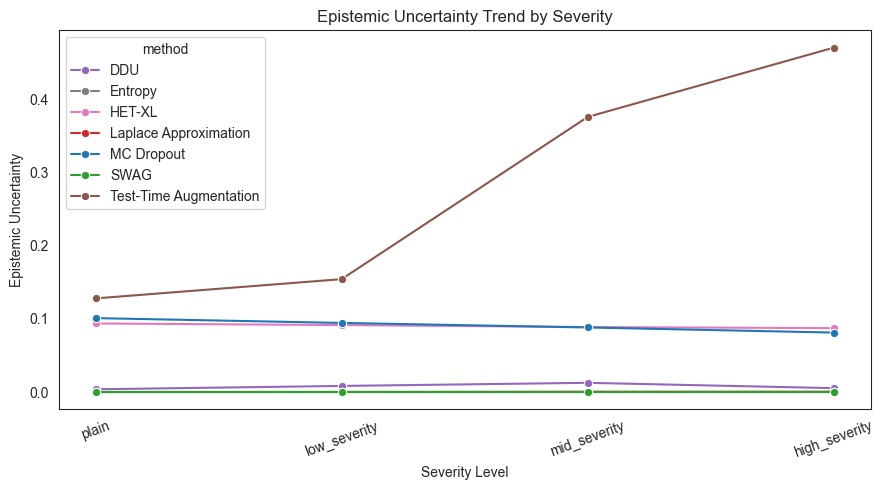

In [11]:
# Dedicated epistemic plot with method-wise lines over severity levels.
epistemic_df = (
    results_df[['method', 'level', 'mean_epistemic_uncertainty']]
    .rename(columns={'mean_epistemic_uncertainty': 'Epistemic Uncertainty'})
    .copy()
)

epistemic_df['level'] = pd.Categorical(
    epistemic_df['level'],
    categories=SEVERITY_ORDER,
    ordered=True,
)
epistemic_df = epistemic_df.sort_values(['method', 'level'])

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=epistemic_df,
    x='level',
    y='Epistemic Uncertainty',
    hue='method',
    marker='o',
    palette=plot_palette,
)
plt.title('Epistemic Uncertainty Trend by Severity')
plt.xlabel('Severity Level')
plt.ylabel('Epistemic Uncertainty')
plt.xticks(rotation=20)
plt.tight_layout()

epistemic_pdf = OUTPUT_DIR / 'epistemic_trend_results_only.pdf'
epistemic_png = OUTPUT_DIR / 'epistemic_trend_results_only.png'
plt.savefig(epistemic_pdf)
plt.savefig(epistemic_png, dpi=200)
print('Saved:', epistemic_pdf)
print('Saved:', epistemic_png)
plt.show()

In [9]:
# User-friendly summary table for quick model comparison on the plain split.
plain_summary = (
    results_df[results_df['level'] == 'plain']
    [['method', 'classification_auroc', 'misclassification_auroc']]
    .sort_values('misclassification_auroc', ascending=False)
    .reset_index(drop=True)
)

print('Plain split ranking (by misclassification AUROC):')
display(plain_summary)

Plain split ranking (by misclassification AUROC):


,method,classification_auroc,misclassification_auroc
0,Laplace Approximation,0.999764,0.972817
1,MC Dropout,0.983379,0.866863
2,Test-Time Augmentation,0.986014,0.713645
3,Entropy,0.859215,0.697983
4,DDU,0.520556,0.577861
5,HET-XL,0.520803,0.521336
6,SWAG,0.500000,0.500000
